# SQL Mini Project - Customer Order Activity Analysis

확장된 고객·주문 데이터를 이용해 고객별 주문 활동과 관리 대상을 분석한다.

## 프로젝트 배경

기존 `retail_lab.db`는 고객 4명, 주문 4건으로 구성되어 있어
고객 순위, 주문 간격, 최근성과 관리 대상 분류를 비교하기에 데이터가 부족했다.

원본 데이터베이스는 보존하고,
학습용 고객과 주문 데이터를 추가한 `retail_lab_day20.db`를 별도로 사용한다.

## 문제 정의

고객 관리 담당자가 유지, 재활성화와 주문 문제 점검 대상의 우선순위를
정할 수 있도록 고객별 주문 횟수, 주문 상태, 최근 주문 경과일과
평균 주문 간격을 고객 단위로 분석한다.

## 분석 질문

1. 고객별 전체 주문 수는 몇 건인가?
2. paid 주문과 cancelled 주문은 각각 몇 건인가?
3. 고객별 최초 주문일과 최근 주문일은 언제인가?
4. 고객의 평균 주문 간격은 며칠인가?
5. 데이터 기준일로부터 최근 주문 후 며칠이 지났는가?
6. 전체 고객 평균보다 주문 활동이 높은 고객은 누구인가?
7. 유지, 재활성화, 첫 구매 활성화와 주문 문제 점검 대상은 누구인가?

## 분석 기준

- 분석 데이터베이스: `retail_lab_day20.db`
- 사용 테이블: `customers`, `orders`
- 연결 키: `customer_id`
- 분석 단위: 고객 1명당 1행
- 기준일: `orders` 테이블의 최대 `order_date`
- 주문 상태: `paid`, `cancelled`

### 활동 상태

- `no_order`: 주문 이력 없음
- `recent`: 최근 주문 후 30일 이하
- `cooling`: 최근 주문 후 31일 이상 60일 이하
- `inactive_candidate`: 최근 주문 후 60일 초과

### 관리 대상

- `activation_candidate`: 주문 이력이 없는 고객
- `order_issue_review`: 취소 주문 수가 결제 주문 수보다 많은 고객
- `retention_priority`: 평균보다 주문이 많고 최근 30일 이내 주문한 고객
- `reengagement_candidate`: 최근 주문 후 60일이 지난 고객
- `general_management`: 그 외 고객

30일과 60일은 학습용 분류 기준이며 실제 업무 정책은 아니다.

In [1]:
# 라이브러리 불러오기
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 프로젝트 경로 설정
project_root = Path.cwd().parent
study_root = project_root.parent.parent

db_path = (
    study_root
    / "SQL"
    / "database"
    / "retail_lab_day20.db"
)

output_dir = project_root / "outputs"

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("프로젝트 경로:", project_root)
print("데이터베이스 경로:", db_path)
print("출력 경로:", output_dir)

프로젝트 경로: d:\Study\Projects\00_foundation_review
데이터베이스 경로: d:\Study\SQL\database\retail_lab_day20.db
출력 경로: d:\Study\Projects\00_foundation_review\outputs


In [3]:
# DB 존재 여부 확인
print("DB 존재 여부:", db_path.exists())

DB 존재 여부: True


In [4]:
# 데이터베이스 연결
conn = sqlite3.connect(db_path)

print("데이터베이스 연결 완료")

데이터베이스 연결 완료


In [5]:
# 고객 수와 주문 수 확인
customer_count_query = """
SELECT
    COUNT(*) AS customer_count
FROM customers
"""

order_count_query = """
SELECT
    COUNT(*) AS order_count
FROM orders
"""

customer_count_df = pd.read_sql(
    customer_count_query,
    conn
)

order_count_df = pd.read_sql(
    order_count_query,
    conn
)

source_customer_count = customer_count_df["customer_count"][0]
source_order_count = order_count_df["order_count"][0]

print("원본 고객 수:", source_customer_count)
print("원본 주문 수:", source_order_count)

원본 고객 수: 30
원본 주문 수: 104


In [6]:
# 주문 상태 확인
status_query = """
SELECT
    status,
    COUNT(*) AS order_count
FROM orders
GROUP BY status
ORDER BY status
"""

status_df = pd.read_sql(
    status_query,
    conn
)

print(status_df)

      status  order_count
0  cancelled           18
1       paid           86


In [7]:
# 분석 기간 확인
date_query = """
SELECT
    MIN(order_date) AS first_order_date,
    MAX(order_date) AS data_reference_date
FROM orders
"""

date_df = pd.read_sql(
    date_query,
    conn
)

print(date_df)

  first_order_date data_reference_date
0       2025-11-25          2026-07-31


In [8]:
# 최종 고객 분석 SQL 작성
query = """
SELECT
    customer_features.customer_id,
    customer_features.customer_name,
    customer_features.region,
    customer_features.grade,
    customer_features.total_order_count,
    customer_features.paid_order_count,
    customer_features.cancelled_order_count,
    customer_features.paid_rate,
    customer_features.first_order_date,
    customer_features.last_order_date,
    customer_features.data_reference_date,
    customer_features.active_period_days,
    customer_features.avg_days_between_orders,
    customer_features.recency_days,
    customer_features.avg_customer_order_count,
    customer_features.order_count_rank,

    CASE
        WHEN customer_features.total_order_count = 0
            THEN 'no_order'

        WHEN customer_features.recency_days <= 30
            THEN 'recent'

        WHEN customer_features.recency_days <= 60
            THEN 'cooling'

        ELSE 'inactive_candidate'
    END AS activity_status,

    CASE
        WHEN customer_features.total_order_count = 0
            THEN 'activation_candidate'

        WHEN customer_features.cancelled_order_count
             > customer_features.paid_order_count
            THEN 'order_issue_review'

        WHEN customer_features.total_order_count
             > customer_features.avg_customer_order_count
             AND customer_features.recency_days <= 30
            THEN 'retention_priority'

        WHEN customer_features.recency_days > 60
            THEN 'reengagement_candidate'

        ELSE 'general_management'
    END AS management_action

FROM (
    SELECT
        customer_comparison.customer_id,
        customer_comparison.customer_name,
        customer_comparison.region,
        customer_comparison.grade,
        customer_comparison.total_order_count,
        customer_comparison.paid_order_count,
        customer_comparison.cancelled_order_count,

        CASE
            WHEN customer_comparison.total_order_count = 0
                THEN 0
            ELSE ROUND(
                customer_comparison.paid_order_count
                * 100.0
                / customer_comparison.total_order_count,
                1
            )
        END AS paid_rate,

        customer_comparison.first_order_date,
        customer_comparison.last_order_date,
        customer_comparison.data_reference_date,
        customer_comparison.active_period_days,
        customer_comparison.avg_days_between_orders,

        CASE
            WHEN customer_comparison.last_order_date IS NULL
                THEN NULL
            ELSE CAST(
                julianday(
                    customer_comparison.data_reference_date
                )
                - julianday(
                    customer_comparison.last_order_date
                )
                AS INTEGER
            )
        END AS recency_days,

        customer_comparison.avg_customer_order_count,
        customer_comparison.order_count_rank

    FROM (
        SELECT
            customer_summary.customer_id,
            customer_summary.customer_name,
            customer_summary.region,
            customer_summary.grade,
            customer_summary.total_order_count,
            customer_summary.paid_order_count,
            customer_summary.cancelled_order_count,
            customer_summary.first_order_date,
            customer_summary.last_order_date,
            customer_summary.active_period_days,
            customer_summary.avg_days_between_orders,

            MAX(
                customer_summary.last_order_date
            ) OVER () AS data_reference_date,

            ROUND(
                AVG(
                    customer_summary.total_order_count * 1.0
                ) OVER (),
                2
            ) AS avg_customer_order_count,

            DENSE_RANK() OVER (
                ORDER BY
                    customer_summary.total_order_count DESC
            ) AS order_count_rank

        FROM (
            SELECT
                order_flow.customer_id,
                order_flow.customer_name,
                order_flow.region,
                order_flow.grade,

                COUNT(
                    order_flow.order_id
                ) AS total_order_count,

                SUM(
                    CASE
                        WHEN order_flow.status = 'paid'
                            THEN 1
                        ELSE 0
                    END
                ) AS paid_order_count,

                SUM(
                    CASE
                        WHEN order_flow.status = 'cancelled'
                            THEN 1
                        ELSE 0
                    END
                ) AS cancelled_order_count,

                MIN(
                    order_flow.order_date
                ) AS first_order_date,

                MAX(
                    order_flow.order_date
                ) AS last_order_date,

                CASE
                    WHEN COUNT(order_flow.order_id) >= 2
                        THEN CAST(
                            julianday(
                                MAX(order_flow.order_date)
                            )
                            - julianday(
                                MIN(order_flow.order_date)
                            )
                            AS INTEGER
                        )
                    ELSE NULL
                END AS active_period_days,

                ROUND(
                    AVG(
                        CASE
                            WHEN order_flow.previous_order_date
                                 IS NOT NULL
                                THEN
                                    julianday(
                                        order_flow.order_date
                                    )
                                    - julianday(
                                        order_flow.previous_order_date
                                    )
                            ELSE NULL
                        END
                    ),
                    1
                ) AS avg_days_between_orders

            FROM (
                SELECT
                    c.customer_id,
                    c.customer_name,
                    c.region,
                    c.grade,
                    o.order_id,
                    o.order_date,
                    o.status,

                    LAG(o.order_date) OVER (
                        PARTITION BY c.customer_id
                        ORDER BY
                            o.order_date,
                            o.order_id
                    ) AS previous_order_date

                FROM customers AS c
                LEFT JOIN orders AS o
                    ON c.customer_id = o.customer_id
            ) AS order_flow

            GROUP BY
                order_flow.customer_id,
                order_flow.customer_name,
                order_flow.region,
                order_flow.grade
        ) AS customer_summary
    ) AS customer_comparison
) AS customer_features

ORDER BY
    CASE management_action
        WHEN 'retention_priority' THEN 1
        WHEN 'order_issue_review' THEN 2
        WHEN 'reengagement_candidate' THEN 3
        WHEN 'activation_candidate' THEN 4
        ELSE 5
    END,
    customer_features.order_count_rank,
    customer_features.customer_id
"""

In [9]:
# SQL 실행
df = pd.read_sql(
    query,
    conn
)

print(df.head())

   customer_id customer_name   region grade  total_order_count  \
0            1           Kim    Seoul   VIP                  9   
1            5           Han    Seoul   VIP                  8   
2            6          Jung    Busan  GOLD                  7   
3            9          Yoon  Daejeon   VIP                  6   
4           25           Bae  Incheon   VIP                  6   

   paid_order_count  cancelled_order_count  paid_rate first_order_date  \
0                 9                      0      100.0       2026-01-15   
1                 8                      0      100.0       2025-12-20   
2                 6                      1       85.7       2026-01-05   
3                 6                      0      100.0       2026-01-07   
4                 6                      0      100.0       2026-01-12   

  last_order_date data_reference_date  active_period_days  \
0      2026-07-30          2026-07-31               196.0   
1      2026-07-31          2026-07-3

In [10]:
# DataFrame 크기 확인
print("최종 결과 행과 열:", df.shape)
print("원본 고객 수:", source_customer_count)

최종 결과 행과 열: (30, 18)
원본 고객 수: 30


In [11]:
# 자료형 확인
print(df.dtypes)

customer_id                   int64
customer_name                   str
region                          str
grade                           str
total_order_count             int64
paid_order_count              int64
cancelled_order_count         int64
paid_rate                   float64
first_order_date                str
last_order_date                 str
data_reference_date             str
active_period_days          float64
avg_days_between_orders     float64
recency_days                float64
avg_customer_order_count    float64
order_count_rank              int64
activity_status                 str
management_action               str
dtype: object


In [12]:
# 결측치 확인
print(df.isna().sum())

customer_id                 0
customer_name               0
region                      0
grade                       0
total_order_count           0
paid_order_count            0
cancelled_order_count       0
paid_rate                   0
first_order_date            5
last_order_date             5
data_reference_date         0
active_period_days          6
avg_days_between_orders     6
recency_days                5
avg_customer_order_count    0
order_count_rank            0
activity_status             0
management_action           0
dtype: int64


In [13]:
# 날짜 자료형 변환
df["first_order_date"] = pd.to_datetime(
    df["first_order_date"]
)

df["last_order_date"] = pd.to_datetime(
    df["last_order_date"]
)

df["data_reference_date"] = pd.to_datetime(
    df["data_reference_date"]
)

print(df.dtypes)

customer_id                          int64
customer_name                          str
region                                 str
grade                                  str
total_order_count                    int64
paid_order_count                     int64
cancelled_order_count                int64
paid_rate                          float64
first_order_date            datetime64[us]
last_order_date             datetime64[us]
data_reference_date         datetime64[us]
active_period_days                 float64
avg_days_between_orders            float64
recency_days                       float64
avg_customer_order_count           float64
order_count_rank                     int64
activity_status                        str
management_action                      str
dtype: object


In [14]:
# 고객 ID 중복 확인
duplicate_customer_count = (
    df["customer_id"]
    .duplicated()
    .sum()
)

print(
    "중복 고객 ID 수:",
    duplicate_customer_count
)

중복 고객 ID 수: 0


In [15]:
# 주문 수 합계 검증
result_order_count = df["total_order_count"].sum()

print("원본 주문 수:", source_order_count)
print("분석 결과 주문 수 합계:", result_order_count)

원본 주문 수: 104
분석 결과 주문 수 합계: 104


In [16]:
# 주문 상태 수 검증
source_paid_count = status_df[
    status_df["status"] == "paid"
]["order_count"].iloc[0]

source_cancelled_count = status_df[
    status_df["status"] == "cancelled"
]["order_count"].iloc[0]

result_paid_count = df["paid_order_count"].sum()
result_cancelled_count = df["cancelled_order_count"].sum()

print("원본 paid 주문 수:", source_paid_count)
print("분석 결과 paid 주문 수:", result_paid_count)

print("원본 cancelled 주문 수:", source_cancelled_count)
print("분석 결과 cancelled 주문 수:", result_cancelled_count)

원본 paid 주문 수: 86
분석 결과 paid 주문 수: 86
원본 cancelled 주문 수: 18
분석 결과 cancelled 주문 수: 18


In [17]:
# 고객 활동 상태별 인원 확인
activity_count = (
    df["activity_status"]
    .value_counts()
)

print(activity_count)

activity_status
recent                17
inactive_candidate     5
no_order               5
cooling                3
Name: count, dtype: int64


In [18]:
# 관리 대상별 인원 확인
management_count = (
    df["management_action"]
    .value_counts()
)

print(management_count)

management_action
retention_priority        9
general_management        7
reengagement_candidate    5
activation_candidate      5
order_issue_review        4
Name: count, dtype: int64


In [19]:
# 관리 대상별 요약
management_summary = df.groupby(
    "management_action"
).agg(
    customer_count=("customer_id", "count"),
    average_order_count=("total_order_count", "mean"),
    average_recency_days=("recency_days", "mean")
)

management_summary = (
    management_summary.reset_index()
)

management_summary["average_order_count"] = (
    management_summary["average_order_count"]
    .round(2)
)

management_summary["average_recency_days"] = (
    management_summary["average_recency_days"]
    .round(1)
)

print(management_summary)

        management_action  customer_count  average_order_count  \
0    activation_candidate               5                 0.00   
1      general_management               7                 2.29   
2      order_issue_review               4                 4.00   
3  reengagement_candidate               5                 3.60   
4      retention_priority               9                 6.00   

   average_recency_days  
0                   NaN  
1                  28.1  
2                  15.8  
3                 114.0  
4                   4.7  


In [20]:
# 유지 우선 고객 확인
retention_customers = df[
    df["management_action"]
    == "retention_priority"
]

retention_customers = retention_customers[
    [
        "customer_id",
        "customer_name",
        "region",
        "grade",
        "total_order_count",
        "last_order_date",
        "recency_days",
        "avg_days_between_orders"
    ]
]

print(retention_customers)

   customer_id customer_name   region  grade  total_order_count  \
0            1           Kim    Seoul    VIP                  9   
1            5           Han    Seoul    VIP                  8   
2            6          Jung    Busan   GOLD                  7   
3            9          Yoon  Daejeon    VIP                  6   
4           25           Bae  Incheon    VIP                  6   
5           21            Ko  Daejeon    VIP                  5   
6           29            Oh    Seoul    VIP                  5   
7            2           Lee    Busan  BASIC                  4   
8           19          Hong  Incheon    VIP                  4   

  last_order_date  recency_days  avg_days_between_orders  
0      2026-07-30           1.0                     24.5  
1      2026-07-31           0.0                     31.9  
2      2026-07-24           7.0                     33.3  
3      2026-07-29           2.0                     40.6  
4      2026-07-31           0.0   

In [21]:
# 주문 문제 점검 고객 확인
issue_customers = df[
    df["management_action"]
    == "order_issue_review"
]

issue_customers = issue_customers[
    [
        "customer_id",
        "customer_name",
        "region",
        "paid_order_count",
        "cancelled_order_count",
        "paid_rate",
        "recency_days"
    ]
]

print(issue_customers)

    customer_id customer_name   region  paid_order_count  \
9             7          Kang  Incheon                 1   
10            3          Park    Seoul                 1   
11           14          Kwon    Daegu                 1   
12           23          Yang    Seoul                 1   

    cancelled_order_count  paid_rate  recency_days  
9                       4       20.0           3.0  
10                      3       25.0           8.0  
11                      3       25.0          11.0  
12                      2       33.3          41.0  


In [22]:
# 재활성화 후보 확인
reengagement_customers = df[
    df["management_action"]
    == "reengagement_candidate"
]

reengagement_customers = reengagement_customers[
    [
        "customer_id",
        "customer_name",
        "region",
        "grade",
        "total_order_count",
        "last_order_date",
        "recency_days",
        "avg_days_between_orders"
    ]
]

print(reengagement_customers)

    customer_id customer_name   region  grade  total_order_count  \
13           15         Hwang  Daejeon    VIP                  5   
14           10          Jang  Gwangju  BASIC                  4   
15           27           Heo  Daejeon  BASIC                  4   
16           17          Song    Seoul  BASIC                  3   
17           20          Jeon    Daegu   GOLD                  2   

   last_order_date  recency_days  avg_days_between_orders  
13      2026-03-20         133.0                     28.8  
14      2026-04-15         107.0                     42.0  
15      2026-04-25          97.0                     39.3  
16      2026-05-25          67.0                     64.0  
17      2026-02-15         166.0                     65.0  


In [23]:
# 첫 구매 활성화 후보 확인
reengagement_customers = df[
    df["management_action"]
    == "reengagement_candidate"
]

reengagement_customers = reengagement_customers[
    [
        "customer_id",
        "customer_name",
        "region",
        "grade",
        "total_order_count",
        "last_order_date",
        "recency_days",
        "avg_days_between_orders"
    ]
]

print(reengagement_customers)

    customer_id customer_name   region  grade  total_order_count  \
13           15         Hwang  Daejeon    VIP                  5   
14           10          Jang  Gwangju  BASIC                  4   
15           27           Heo  Daejeon  BASIC                  4   
16           17          Song    Seoul  BASIC                  3   
17           20          Jeon    Daegu   GOLD                  2   

   last_order_date  recency_days  avg_days_between_orders  
13      2026-03-20         133.0                     28.8  
14      2026-04-15         107.0                     42.0  
15      2026-04-25          97.0                     39.3  
16      2026-05-25          67.0                     64.0  
17      2026-02-15         166.0                     65.0  


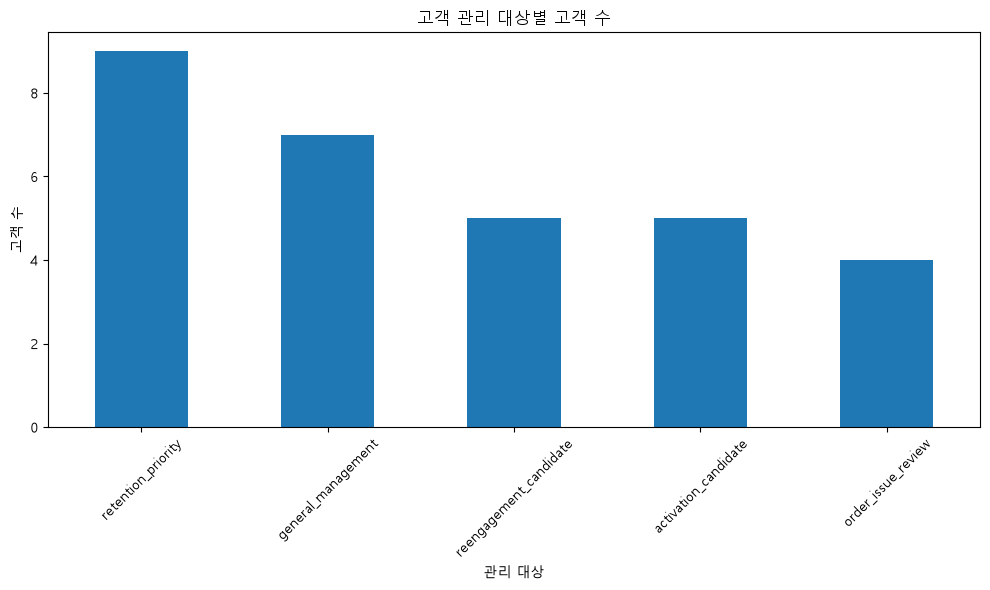

그래프 저장 경로: d:\Study\Projects\00_foundation_review\outputs\customer_management_action.png


In [25]:
# 관리 대상별 고객 수 그래프
management_count.plot.bar(
    figsize=(10, 6)
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.title("고객 관리 대상별 고객 수")
plt.xlabel("관리 대상")
plt.ylabel("고객 수")
plt.xticks(rotation=45)
plt.tight_layout()

figure_path = (
    output_dir
    / "customer_management_action.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("그래프 저장 경로:", figure_path)

In [26]:
# 최종 고객 분석 CSV 저장
output_path = (
    output_dir
    / "customer_order_mini_project.csv"
)

df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d"
)

print("고객 분석 CSV 저장 경로:", output_path)

고객 분석 CSV 저장 경로: d:\Study\Projects\00_foundation_review\outputs\customer_order_mini_project.csv


In [27]:
# 관리 대상 요약 CSV 저장
summary_path = (
    output_dir
    / "customer_management_summary.csv"
)

management_summary.to_csv(
    summary_path,
    index=False,
    encoding="utf-8-sig"
)

print("관리 대상 요약 CSV 저장 경로:", summary_path)

관리 대상 요약 CSV 저장 경로: d:\Study\Projects\00_foundation_review\outputs\customer_management_summary.csv


In [28]:
# 저장된 파일 확인
saved_df = pd.read_csv(
    output_path
)

saved_summary = pd.read_csv(
    summary_path
)

print(saved_df.head())
print(saved_summary)

print("고객 분석 CSV 존재:", output_path.exists())
print("관리 대상 요약 CSV 존재:", summary_path.exists())
print("그래프 존재:", figure_path.exists())

   customer_id customer_name   region grade  total_order_count  \
0            1           Kim    Seoul   VIP                  9   
1            5           Han    Seoul   VIP                  8   
2            6          Jung    Busan  GOLD                  7   
3            9          Yoon  Daejeon   VIP                  6   
4           25           Bae  Incheon   VIP                  6   

   paid_order_count  cancelled_order_count  paid_rate first_order_date  \
0                 9                      0      100.0       2026-01-15   
1                 8                      0      100.0       2025-12-20   
2                 6                      1       85.7       2026-01-05   
3                 6                      0      100.0       2026-01-07   
4                 6                      0      100.0       2026-01-12   

  last_order_date data_reference_date  active_period_days  \
0      2026-07-30          2026-07-31               196.0   
1      2026-07-31          2026-07-3

In [29]:
# 데이터베이스 연결 종료
conn.close()

print("데이터베이스 연결 종료")

데이터베이스 연결 종료


## 핵심 결과

- 분석 대상 고객은 30명이고 전체 주문은 104건이다.
- paid 주문은 86건, cancelled 주문은 18건이다.
- 전체 주문 중 paid 주문의 비율은 약 82.7%이다.
- 전체 고객의 평균 주문 수는 약 3.47건이다.
- 최근 30일 이내 주문한 recent 고객은 17명이다.
- 최근 주문 후 31일 이상 60일 이하인 cooling 고객은 3명이다.
- 최근 주문 후 60일이 지난 inactive_candidate 고객은 5명이다.
- 주문 이력이 없는 no_order 고객은 5명이다.

### 관리 대상 결과

- retention_priority: 9명
- order_issue_review: 4명
- reengagement_candidate: 5명
- activation_candidate: 5명
- general_management: 7명

retention_priority 고객은 평균 주문 수가 6건이고 평균 최근 주문 경과일이 약 4.7일로,
다른 고객군보다 주문 횟수가 많고 최근 활동도 유지되고 있다.

reengagement_candidate 고객은 평균 주문 수가 3.6건이지만
평균 최근 주문 경과일이 약 114일로 주문 공백이 길다.

order_issue_review 고객은 최근 주문 활동은 존재하지만
cancelled 주문 수가 paid 주문 수보다 많아 주문 과정의 문제를 추가로 확인할 필요가 있다.

activation_candidate 고객 5명 중 4명은 Busan 지역 고객으로,
지역별 가입 및 첫 주문 과정에 차이가 있는지 추가 확인할 수 있다.

## 업무 제안

### 유지 우선 고객

`retention_priority` 고객은 전체 고객 평균보다 주문 횟수가 많고
최근 30일 이내에도 주문한 고객이다.

반복 주문 활동이 유지되도록 우선 관리 대상이나 혜택 제공 후보로 검토할 수 있다.

### 재활성화 후보

`reengagement_candidate` 고객은 과거 주문 이력이 있지만
최근 주문 후 60일 이상 지난 고객이다.

과거 주문 활동과 현재 주문 공백의 원인을 확인한 후
재활성화 캠페인 후보로 검토할 수 있다.

### 첫 구매 활성화 후보

`activation_candidate` 고객은 고객 정보는 있지만 주문 이력이 없다.

가입 후 첫 주문 과정에서 상품 탐색, 결제, 가격 또는 안내 문제가 있었는지
추가 데이터를 통해 확인할 필요가 있다.

### 주문 문제 점검 대상

`order_issue_review` 고객은 cancelled 주문 수가 paid 주문 수보다 많다.

결제 실패, 재고 부족, 배송 문제 또는 고객 변심 등
구체적인 취소 사유를 추가로 수집해 확인할 필요가 있다.

이 내용은 분석 결과를 바탕으로 한 검토 제안이며,
실제 캠페인 효과나 문제 원인을 확정하는 결론은 아니다.

## 분석 한계

1. 추가한 고객과 주문 데이터는 SQL 학습을 위한 가상 데이터다.
2. orders 테이블에 상품 ID, 수량과 주문 금액이 없다.
3. 고객별 주문 횟수는 분석할 수 있지만 매출 기여도와 수익성은 판단할 수 없다.
4. 고객 가입일이 없어 가입 후 첫 주문까지 걸린 기간을 계산할 수 없다.
5. 주문 취소 사유가 없어 취소가 많은 원인을 직접 확인할 수 없다.
6. 최근 30일과 60일 기준은 학습용 업무 규칙이다.
7. 최근 주문 공백만으로 고객 이탈을 확정할 수 없다.
8. 고객 관리 분류는 통계 검정이나 머신러닝 예측 결과가 아니다.
9. 고객 연락이나 캠페인의 실제 효과는 별도의 실험을 통해 검증해야 한다.